# 1. 环境安装

- 环境要求
    - python 3.10以上版本

- 安装matplotlib模块

In [1]:
!pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple/

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/


- 验证matplotlib安装情况

In [2]:
!pip list | find "matplotlib"

matplotlib                               3.8.3
matplotlib-inline                        0.1.6


- 查看matplotlib安装的情况

In [3]:
!pip show matplotlib

Name: matplotlib
Version: 3.8.3
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: matplotlib-users@python.org
License: PSF
Location: c:\users\thinkpad\appdata\roaming\python\python310\site-packages
Requires: contourpy, cycler, fonttools, kiwisolver, numpy, packaging, pillow, pyparsing, python-dateutil
Required-by: gradio, insightface, seaborn, unstructured-inference, visualdl


- 检查相关依赖包或者模块

In [5]:
!pip check

arxiv 2.1.0 has requirement requests==2.31.0, but you have requests 2.32.3.
chromadb 0.5.23 has requirement tokenizers<=0.20.3,>=0.13.2, but you have tokenizers 0.21.0.
grpcio-tools 1.47.5 has requirement protobuf<4.0dev,>=3.12.0, but you have protobuf 5.29.1.
pymilvus-distributed 0.0.63 has requirement mmh3==2.3.1, but you have mmh3 5.0.1.


- 上面的安装情况，多所有Python模块都是一样的。

# 2. Matplotlib的核心对象

- 既然matplotlib是面向对象的，对面向对象编程来说，完成所有可视化任务都是由对象负责，我们就行掌握每个对象的关系与使用开始。

- 对象的关系

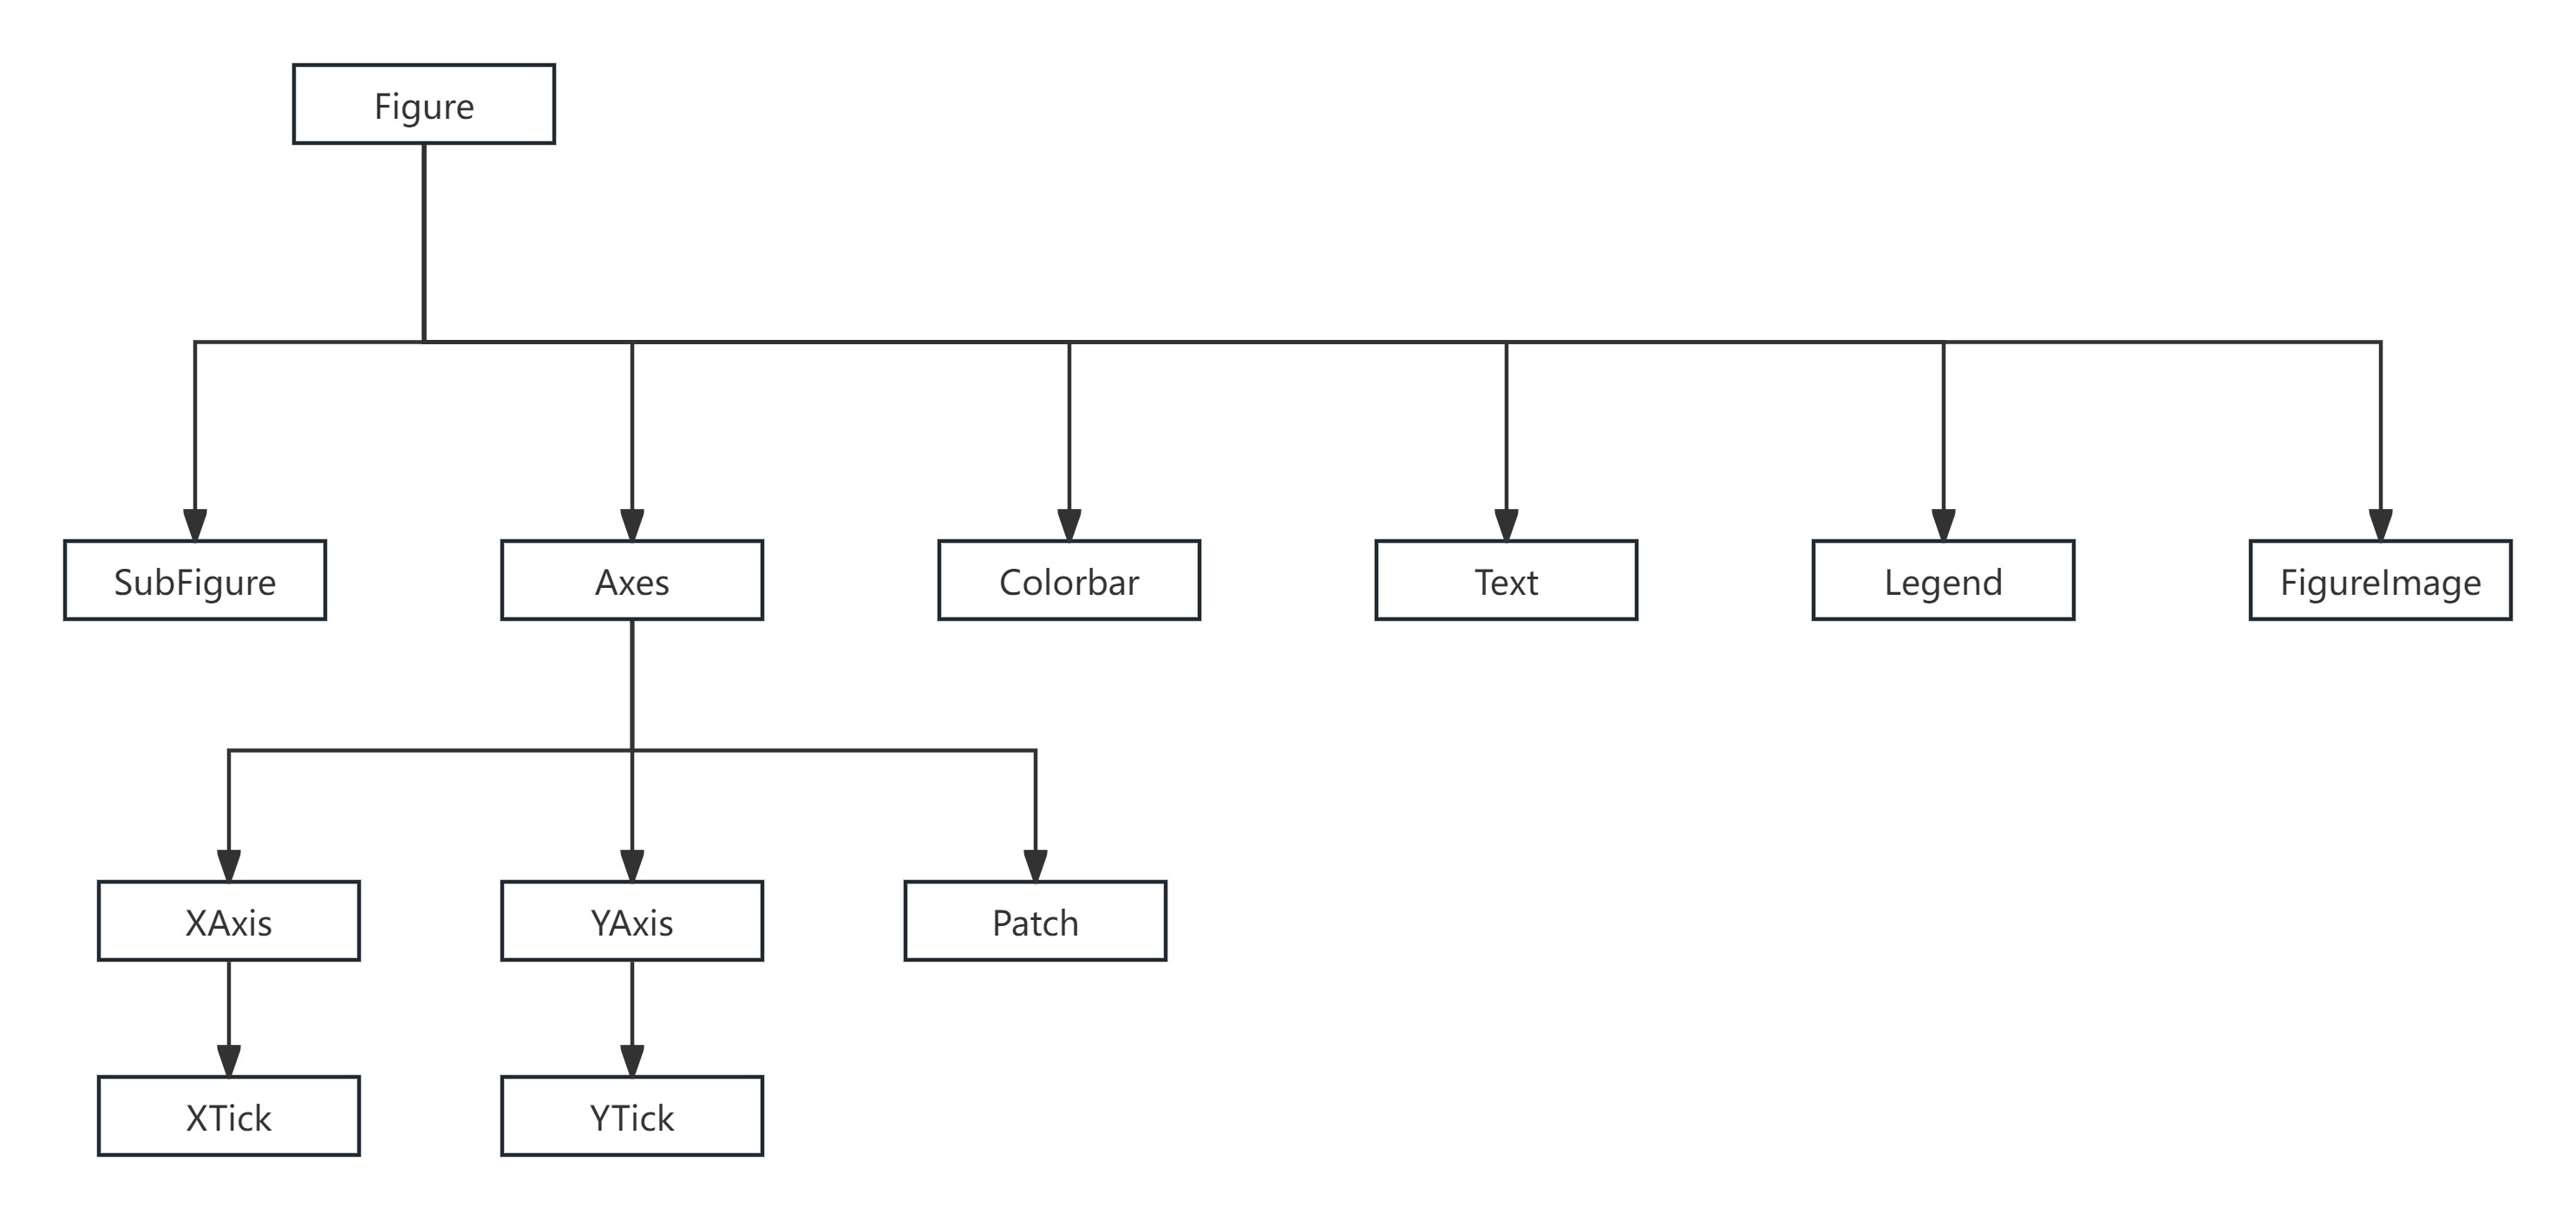

- 这些对象的关系一般都是通过函数来建立，每个对象同时有很多属性进行修饰。
    - Figure负责画布
    - Axes负责坐标系
    - Axis负责坐标轴
    - Tick负责坐标刻度

- 其中Axes是我们主要使用的对象，该对象的核心功能是画图，画图都是由一系列函数提供。

- 上面的对象大部分是使用函数直接创建，而不是使用构造器构造，甚至包括Figure对象。

- 更全的关系可以使用下面官方的对象图说明。

![Matplotlib对象图](Matplotlib的对象结构.svg)

## 2.1.Figure对象

- 本身并不直接绘制任何图形（图形绘制由Axes对象负责），而是负责管理和包含所有其他可视化元素。其主要功能是：
    - 顶级容器：如果把这种容器关系看成树状关系，Figure就是所有对象的根对象，所有其他元素（如坐标系，坐标轴、图形、文本等）都位于其上或其中。
    - 创建坐标系：通过 Figure 对象来创建和管理一个或多个 Axes（坐标系/子图），Axes这是实际进行绘图的对象，也是绘图的容器。
    - 管理输出：负责将图形保存为图像文件（如 PNG, PDF, SVG 等）或显示在屏幕上。

- Figure对象还有很多属性，可以设置整个图形的尺寸、分辨率、背景色、边框等全局属性。

### (1) 使用构造器创建Figure对象

 - 使用构造器创建figure对象
     - 使用这种方式创建的图，因为没有显示平台，所以无法直接在jupyter Notebook中直接显示，只能直接保存为图像文件。

In [19]:
from matplotlib.figure import Figure

fig = Figure(facecolor='gray')
fig.savefig("figure.png")

- 如果想在jupyer Notebook中显示，有两种方法：
    - 可以使用Notebook内置的IPython对象display显示
    - 使用matplotlib的inline指令,这种方法就必须使用

- 使用IPython的display方法显示
    - 该方法需要有Axes坐标系

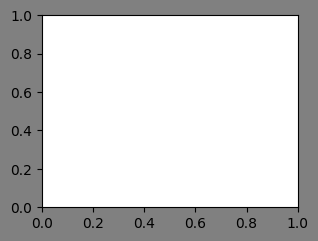

In [37]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
fig.add_axes((0.1, 0.1, 0.8, 0.8))   # 需要有内容才能显示
display(fig)

- 上面`%matplotlib inline`目前已经是默认，可以省略。

### (2) 使用pyplot的figure函数创建Figure对象

- 上面使用Ipython的diaplay显示Figure对象，实际显示的是空，但是在Figure对象中创建一个Axes对象就能显示，是因为真正的图像是由FigureCanvas，因为在创建Axes的时候，默认创建FigureCanvas对象。
- 实际上，Matplotlib只负责可视化绘图，绘制在哪里，这个由不同的托管对象来完成。比如显示在Notebook，或者Qt的GUI，或者Web页面等中。
- 维护这些对象间的关系，比较累赘，所以matplotlib中提供一些门面函数（一种设计与编程模式）封装这些对象关系的维护，最终用户调用起来简单方便。matplotlib提供pyplot模块，其中提供很多方法，给我们提供更加简单方便的使用方式。

- 使用matplotlib.pyplot的figure函数创建Figure对象

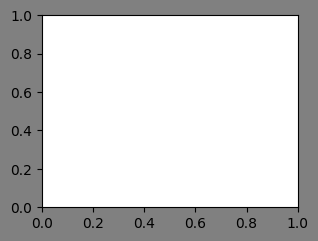

In [46]:
import matplotlib.pyplot as plt
# 创建一个新的 Figure
fig = plt.figure(figsize=(3.2, 2.4), facecolor='gray')
fig.add_axes((0.1, 0.1, 0.8, 0.8))   # 需要有内容才能显示
plt.show()

- 可以利用FigureCanvas把matplotlib的图形显示在其他平台上。

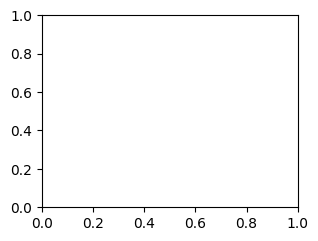

In [49]:
%matplotlib inline
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from IPython.display import display

# 创建支持 3D 的图形
fig = Figure(figsize=(3.2, 2.4))
canvas = FigureCanvasAgg(fig)    # 这个今后可以替换成Qt的Canvas，Web的Canvas，这样图形可以在QT的GUI界面，与Web的HTML中显现。

fig.add_axes((0.1, 0.1, 0.8, 0.8))   # 需要有内容才能显示
# 渲染并显示
canvas.draw()
display(fig)

- 使用`from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg as FigureCanvas`可以在Qt中绘制。
- 在Web中显示，可以把FigureCanvas的数据缓冲成二进制，并使用Base64算法加密成字符串，然后在客户端解码显示，也可以利用Figcanvas的print_png或者print_jpg等函数直接把FigureCanvas的数据编码成图像格式直接输出。

```python
fig = Figure(figsize=(12, 8), facecolor='#f8f9fa', dpi=120)
canvas = FigureCanvasAgg(fig)
buf = io.BytesIO()
canvas.print_png(buf)
# 下面利用HTTP协议的Response对象，直接把图像二进制数据写入IOStream即可。不同Web CGI有细微差异。
```

## 2.2.Axes对象

- Axes对象由Figure管理，Figure是容器，Axes是组件。在创建Axes对象的时候，注意这种包含依附关系的关联。

### (1) 使用Axes构造器创建

- 尽管我们大部分时候不推荐使用Axes构造器构造对象，但是我们还是使用一个例子来说明其构造器的使用。

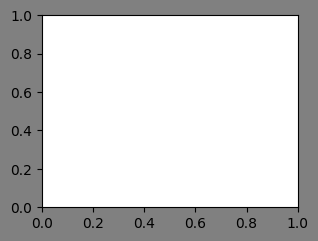

In [4]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure
from matplotlib.axes import Axes

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')

# 创建Axes对象（指定figure容器）
axes = Axes(fig, [0.1, 0.1, 0.8, 0.8])
# 绑定axes与figure的关系
fig.add_axes(axes)

display(fig)

- 上面代码中，Figure对象与Axes对象的依附关系在创建的时候需要指定，并且需要使用`add_axes`函数显式绑定，这么做明显对使用者来说是多于的，这种方式我们需要了解，但是不推荐使用。
- 在使用Axes构造器创建的时候，后面的`[0.1, 0.1, 0.8, 0.8]`用来指定坐标系在画布上的区域位置与大小，这个参数需要指定。具体的Axes详细构造，我们在后面需要说明，这里仅仅是通过对象创建直观认识Axes而已。

### (2) 使用Figure对象的函数创建Axes对象

- 使用Figure对象的函数构建Axes对象是常用的推荐方式。在Figure对象中有三个函数可以使用：
    - `Figure.add_axes`
    - `Figure.add_subplot`
    - `Figure.subplots`

- `add_axes`函数可以显式绑定Figure对象与Axes的关系，其实还可以直接创建，只需要参数设置为创建Axes对象必须得参数就行。

- 使用`add_axes`直接创建对象。这里我们先简单体验，创建的详细参数后面会介绍，详细的参数可以处理可视化的细节，产生更好的用户的数据可视化体验。

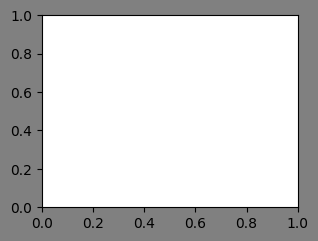

In [5]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
# 绑定axes与figure的关系
fig.add_axes([0.1, 0.1, 0.8, 0.8])

display(fig)

- 使用`Figure.add_subplot`创建对象（一个或者多个）

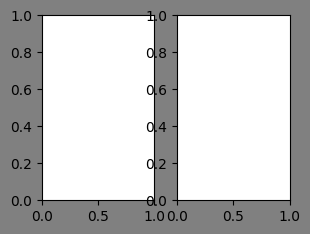

In [7]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
# 绑定axes与figure的关系
fig.add_subplot(121)  # 其中参数121格式是(rows, cols, index),含义是行数，列数与坐标系编号
axes = fig.add_subplot(122)  # 返回Axes对象，可以通过Axes对象对坐标系属性进行设置，得到更好的可视化体验。

display(fig)

- 上面`121`表示是计划创建1行2列的坐标系，当前创建的是第1个
- 上面`122`表示是计划创建1行2列的坐标系，当前创建的是第2个
- 上面调用`add_subplot`后，会返回Axes对象，便于使用者做更加细节的参数调整。

- 使用`Figure.subplots`创建对象（一个或多个）

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


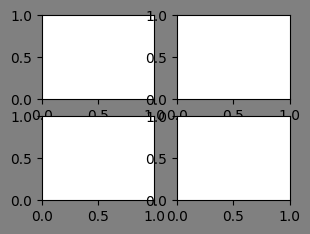

In [11]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
# 绑定axes与figure的关系
ax = fig.subplots(2,2)  # 创建2行2列的4个坐标系
print(ax) # 返回创建的四个坐标系，使用二维数组的方式
display(fig)

- `subplots`一次性创建一个或者多个坐标系，简化了批量创建坐标系。尽管`add_subplot`函数也是在多个坐标系环境中创建，但是每次只能创建一个。

## 2.3.Axis对象

- Axis是坐标系的坐标轴，一般都不会直接创建，而是在创建坐标系的时候直接创建，我们只需要直接通过Axes对象访问Axis对象，对坐标系的坐标轴进行更加详细的属性设置，生成更好体验的可视化效果即可。

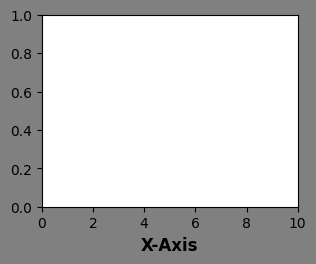

In [14]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# 控制坐标系的坐标轴
xaxis = axes.xaxis
yaxis = axes.yaxis

# 设置坐标轴的标签
xaxis.set_label_text('X-Axis', fontsize=12, fontweight='bold')  # 可以使用汉字
# 这是坐标轴的刻度
xaxis.set_ticks([0, 2, 4, 6, 8, 10])

display(fig)

- 因为matplotlib的默认字体库不存在，显示汉字存在问题，后面matplotlib的环境设置使用专门的主题来讲解，我们这里暂时采用英文回避这个问题。

## 2.4.Tick对象

- Tick对象负责坐标轴上刻度，包括刻度线与刻度标签。与坐标轴一样，在创建Axes坐标系对象的时候，都提供默认创建好的Tick对象，我们一般直接访问，设置更加详细的属性来控制可视化输出效果。
- 我们需要通过Axis对象的`get_major_ticks()`与`get_minor_ticks()`获取Tick对象。

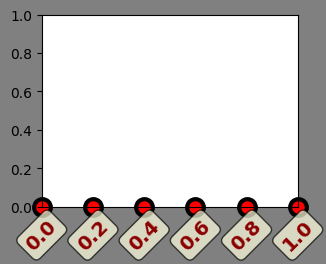

In [20]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# 控制坐标系的坐标轴
xaxis = axes.xaxis
yaxis = axes.yaxis

# 通过Axis对象获取Tick刻度（主（长）刻度）
xticks_maj = xaxis.get_major_ticks()    # 刻度很多，返回的刻度数组。
# 通过Axis对象获取Tick刻度（副（短）刻度）
xticks_min = xaxis.get_minor_ticks()

# 下面是刻度的属性操作
for i, tick in enumerate(xticks_maj):
    # 设置刻度线属性
    tick.tick1line.set_color('red')
    tick.tick1line.set_markersize(12)
    tick.tick1line.set_markeredgewidth(3)
    tick.tick1line.set_marker('o')  # 圆形刻度
    
    # 设置刻度标签属性
    tick.label1.set_fontsize(14)
    tick.label1.set_fontweight('bold')
    tick.label1.set_color('darkred')
    tick.label1.set_rotation(45)
    tick.label1.set_backgroundcolor('lightyellow')
    tick.label1.set_bbox(dict(boxstyle="round,pad=0.3", 
                            facecolor='lightyellow', 
                            alpha=0.7))

display(fig)

## 2.5. Patch对象

- Patch对象实际就是绘制的各种几何图形与图像，一般不会通过创建Patch对象来使用，而是直接使用Axes对象的函数直接绘制，但是我们可以了解这些几何图形对象的创建过程与使用。

- 下面是Patch对象的子对象类型

![Patch对象的子对象.png](Matplotlib的Patch对象子对象.svg)

- 这些是图形的基本元素，一般都是组合构成用户需要的图形，比如箭头与线段构成箭头线。

- 线条使用Line2D对象负责，不在Patch中。

### (1) 创建并绘制Patch与Line2D对象

- 绘制Line2D:
    - Line2D对象与Axes的关系是通过Axes对象的`add_artist`函数绑定并完成绘制。

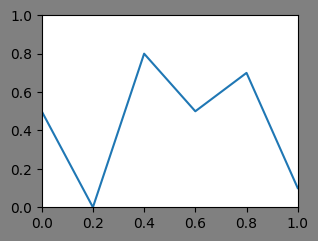

In [24]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure
from matplotlib.lines import Line2D

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# 创建线段
line = Line2D(xdata=[0, 0.2, 0.4, 0.6, 0.8, 1.0], ydata=[0.5, 0, 0.8, 0.5, 0.7, 0.1])
# 添加线段到坐标系，并绘制
axes.add_artist(line)

display(fig)

- 绘制Patch对象，我们这里使用Ellipse来举例。

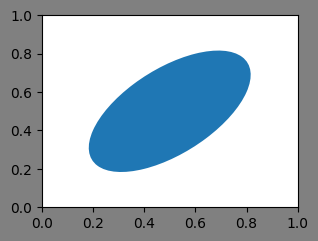

In [29]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure
from matplotlib.patches import Ellipse

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# 创建椭圆
ellipse = Ellipse(xy=(0.5, 0.5), width=0.8, height=0.4, angle=45)  # 角度是反时针，单位是角度，不是弧度
# 添加椭圆到坐标系，并绘制
axes.add_artist(ellipse)

display(fig)

- 在matplotlib中大部分都使用角度，而不是使用弧度，在Ellipse中的angle参数使用的也是角度。
- 我们这里没有深入介绍Patch与Line2D的各种属性，包括颜色，线条样式等更多属性。

### (2) 使用Axes提供的函数直接绘制

- 某些时候需要绘制这些基本的图形元素，但是大部分绘制的是对用户有分析价值的、由多个图形元素构成的图形。在Axes中提供了很多函数完成这些综合绘制，这些函数通常都会返回这些图形对象，可以通过这些返回对象，进行更多的属性设置。
- 组合图形一般在`matplotlib.collections`模块中实现。

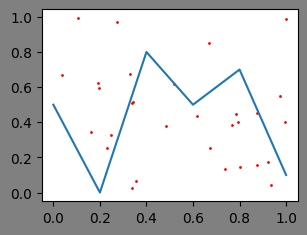

In [36]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# 绘制折线
lines = axes.plot([0, 0.2, 0.4, 0.6, 0.8, 1.0], [0.5, 0, 0.8, 0.5, 0.7, 0.1])
print(lines)
# 绘制散点(使用随机函数产生随机点, 一共n个随机点)
n = 30
import random
x = [random.random() for _ in range(n)]
y = [random.random() for _ in range(n)]
points = axes.scatter(x=x, y=y, s=1, c="r") # 注意上面不能使用x与y的形式参数，而这里可以，这个要根据官方文档来使用。
print(points)
display(fig)

- collections的组合对象在官方文档有一个图来说明。

![collections对象](Matplotlib的collections对象子对象.svg)

## 2.6.Text对象

- 在Matplotlib中大量使用标题文本，文本都是通过Text转换文本为图形图像，而且提供文本的各种格式解析，以及富文本渲染。比如通过Text我们可以使用Latex语法，产生更加丰富的可视化输出效果。

### (1) 使用Text构造器构造对象

- 下面是显式使用Text对象的例子。

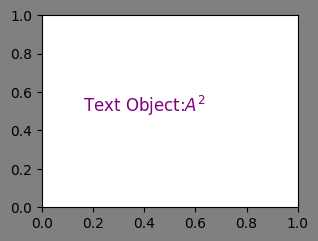

In [42]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure
from matplotlib.text import Text

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

text = Text(x=0.4, y=0.5, text='Text Object:$A^2$', fontsize=12, color='purple', ha='center')
axes.add_artist(text)

display(fig)

- 上面`$A^2$`就是Latex语法描述的一个数学符号:A的平方（$A^2$）

### (2) 使用Axes函数创建Text对象

- 下面是隐式使用Text的例子。

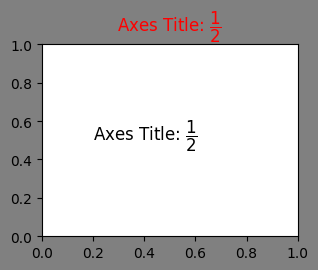

In [49]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure
from matplotlib.text import Text

fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# 隐式文本对象 - 标题
text1 = axes.set_title("Axes Title: $\dfrac{1}{2}$")
text1.set_color("red")  # 设置文本的颜色属性

# 隐式文本对象 - 文本绘制
text2 = axes.text(0.2, 0.5, "Axes Title: $\dfrac{1}{2}$")
text2.set_fontsize(12) # 文本的字体尺寸属性
display(fig)

## 2.7.Legend对象

- Legend负责图例，用来说明图形，图例是与Axes中绘制的数据有关。

### (1) 使用Legend构造器构造对象

- Legend对象与上面的其他对象都是Artist类型，使用模式都统一一样。

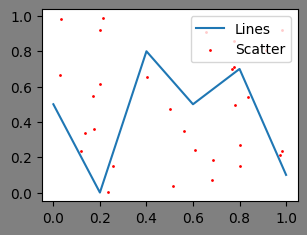

In [62]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure


fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# 绘制折线
lines = axes.plot([0, 0.2, 0.4, 0.6, 0.8, 1.0], [0.5, 0, 0.8, 0.5, 0.7, 0.1])
print(lines)
# 绘制散点(使用随机函数产生随机点, 一共n个随机点)
n = 30
import random
x = [random.random() for _ in range(n)]
y = [random.random() for _ in range(n)]
points = axes.scatter(x=x, y=y, s=1, c="r") # 注意上面不能使用x与y的形式参数，而这里可以，这个要根据官方文档来使用。
print(points)
# 创建图例
from matplotlib.legend import Legend
legend = Legend(axes, (lines[0], points), ('Lines', 'Scatter'), loc='upper right')
axes.add_artist(legend)

display(fig)

- `legend = Legend(axes, (lines[0], points), ('Legend-1', 'Ledend-2'), loc='upper right')`代码解释：
    - axes是Legend对象所在容器
    - `(lines[0], points)`是需要显示的图例，其中必须是Artist对象，而且不支持Artist对象的数组。
    - `loc='upper right')`指定图例在坐标系中显示的位置。`upper right`表示右上角。

### (2) 使用Axes对象的legend函数创建对象

- 在大部分情况，都会显示坐标系中所有图形的图例，可以直接使用Axes的legend函数进行默认处理。
    - legend可以自动侦测，也可以通过参数定制。

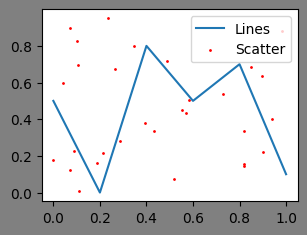

In [61]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure


fig = Figure(figsize=(3.2, 2.4), facecolor='gray')
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# 绘制折线
lines = axes.plot([0, 0.2, 0.4, 0.6, 0.8, 1.0], [0.5, 0, 0.8, 0.5, 0.7, 0.1], label="Lines") # 注意标签属性
print(lines)
# 绘制散点(使用随机函数产生随机点, 一共n个随机点)
n = 30
import random
x = [random.random() for _ in range(n)]
y = [random.random() for _ in range(n)]
points = axes.scatter(x=x, y=y, s=1, c="r", label="Scatter") # 注意标签属性
print(points)

axes.legend()  # 自动侦测，默认右上角。
display(fig)

- 使用这种自动侦测的方式，必须在创建Artist的时候，需要指定Label标签属性。
    - `lines = axes.plot([0, 0.2, 0.4, 0.6, 0.8, 1.0], [0.5, 0, 0.8, 0.5, 0.7, 0.1], label="Lines")`
    - `points = axes.scatter(x=x, y=y, s=1, c="r", label="Scatter") `

## 2.8.Colorbar对象

- Colorbar，负责颜色标识，通过使用颜色来表示数据。我们还是使用两种方式来使用Colorbar。
- 颜色有的时候是可视化中非常重要的表达方式，可以增加数据表达的维度，当然更加复杂的颜色处理，

### (1) 使用构造器构造构造Colorba对象

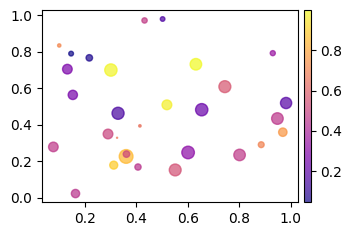

In [97]:
%matplotlib inline
from IPython.display import display
from matplotlib.figure import Figure
from matplotlib.colorbar import Colorbar
from matplotlib.colors import ListedColormap, Normalize     
from matplotlib.cm import ScalarMappable

fig = Figure(figsize=(3.2, 2.4))
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

n = 30
import random
x = [random.random() for _ in range(n)]
y = [random.random() for _ in range(n)]
c = [random.random() for _ in range(n)]
s = [random.random() * 100 for _ in range(n)]
points = axes.scatter(x, y, c=c, s=s, cmap='plasma', alpha=0.7) # 注意plasma颜色图

cax = fig.add_axes([0.92, 0.1, 0.02, 0.8]) 
cbar = Colorbar(cax, points, orientation='vertical') # 使用scatter绘制中的cmap来作为颜色条的颜色

display(fig)

- 上面我们利用了可视化数据的颜色来构造Colorbar对象，实际我们可以自己定义颜色来形成颜色条。后面有专门主题来介绍颜色相关知识。

### (2) 使用pyplot的colorbar函数创建Colorbar对象

- 使用pyplot提供的函数来完成Colorbar对象创建，关于pyplot我们会提供专门的主题来说明。

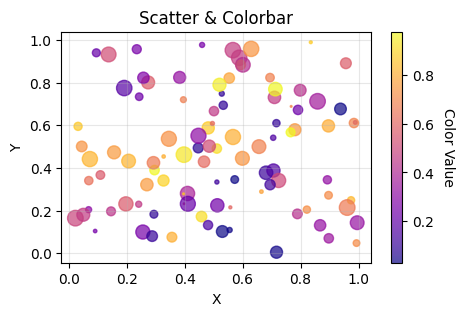

In [100]:
import matplotlib.pyplot as plt

# 创建数据
n = 100
import random
x = [random.random() for _ in range(n)]
y = [random.random() for _ in range(n)]
c = [random.random() for _ in range(n)]
s = [random.random() * 128 for _ in range(n)]

# 创建散点图
plt.figure(figsize=(5, 3))
scatter = plt.scatter(x, y, c=c, s=s, cmap='plasma', alpha=0.7)

# 添加颜色条
cbar = plt.colorbar(scatter)
cbar.set_label('Color Value', rotation=270, labelpad=15)

plt.title('Scatter & Colorbar')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.show()

- 使用pyplot创建Colorbar对象，很多工作会被pyplot自动处理，对使用者非常友好，使用简单高效。

----